*DistilBERT Model on Imbalanced data*

This notebook presents training the DistilBERT on imbalanced dataset.To ensure uniformity, as this is a comparative analysis study,the same data preprocessing and preparation techniques and the same hyperparmeters settings for BERT are used.

In [ ]:
###importing necesaary libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification, create_optimizer
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# Downloading stopwords if not already downloaded
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Loading data
data = pd.read_csv('Service_tickets.csv')



# Function to clean text
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z\s]', '', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

data['Cleaned_Document'] = data['Document'].apply(clean_text)

#Defining DataFrame to have columns needed
data = data[['Cleaned_Document', 'Topic_group']]

# Encode category labels using category codes
data["encoded_text"] = data["Topic_group"].astype('category').cat.codes


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Data Preparation for BERT: Splitting, Tokenization, and Encoding**

Data is split into Training and Test Sets using stratified spliting to ensure the class  distribution in the training and test sets represents the overall class distribution in the  dataset.A further Split of the train data into train and validation Sets for validationg the model and for hyperparameter tuning during training.The test split is reserved for model evaluation after training.

DistilBertTokenizer is used  for tokenizing the text data by converting them into tokenized sequences, and theyre truncated if longer than 512 tokens set limit,
Padding is done for texts shorter than 512tokens to have equal lenght for the sequences.

Converted the train,test and validation sets labels and the tokenized encodings to Numpy arrays for compatitbilty with tensorflow libraries  and also facilitate efficient batch processing and manipulation and Computation efficiency.


In [ ]:
# Splitting the data into training (80%) and test (20%) sets
train_data, test_data = train_test_split(data, test_size=0.2, stratify=data['Topic_group'], random_state=42)

# Spliting the training data into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_data['Cleaned_Document'].tolist(),
    train_data['encoded_text'].tolist(),
    test_size=0.2,
    stratify=train_data['encoded_text'],
    random_state=42
)

# Tokenizing the texts
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(test_data['Cleaned_Document'].tolist(), truncation=True, padding=True, max_length=512)


#converting to Numoy arrays
train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_data['encoded_text'].tolist())

train_encodings = {key: np.array(train_encodings[key]) for key in train_encodings}
val_encodings = {key: np.array(val_encodings[key]) for key in val_encodings}
test_encodings = {key: np.array(test_encodings[key]) for key in test_encodings}


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Loading,compiling and training

pre-trained DistilBERT model (distilbert-base-uncased) is loaded from Hugging face with a specific model for sequence classification with a number of output labels equal to the number of classes The model is compiled with a custom optimizer and a loss function provided by Hugging Face and accuracy is set as the metric to monitor and Hyperparameters are configured, The tokenized training, validation, and test datasets are converted into TensorFlow datasets to leverage TensorFlow's optimizations for data loading, transformation, and feeding data to the model during training, and are batched according to the specified batch sizes. The model is compiled and trained

In [ ]:
# Loading and compiling DistilBERT model
model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(data['Topic_group'].unique()))


# Defining hyperparameters
initial_learning_rate = 2e-5
number_epochs = 10
batch_size_train = 16
batch_size_val = 64
steps_per_epoch = len(train_encodings['input_ids']) // batch_size_train
number_train_steps = steps_per_epoch * number_epochs
warmup_steps = 500

# Creating optimizer
optimizer, schedule = create_optimizer(
    init_lr=initial_learning_rate,
    num_train_steps=number_train_steps,
    num_warmup_steps=warmup_steps
)

# Compiling the model
model.compile(optimizer=optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

# Converting encodings to TensorFlow datasets and batch them
train_dataset = tf.data.Dataset.from_tensor_slices((train_encodings, train_labels)).shuffle(len(train_labels)).batch(batch_size_train)
val_dataset = tf.data.Dataset.from_tensor_slices((val_encodings, val_labels)).batch(batch_size_val)
test_dataset = tf.data.Dataset.from_tensor_slices((test_encodings, test_labels)).batch(batch_size_val)

# Adding early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Training the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=number_epochs, callbacks=[early_stopping])

# Evaluating the model on the test set
preds = model.predict(test_dataset)
y_pred = np.argmax(preds.logits, axis=-1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Computing metrics
conf_matrix = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/7


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
1914/1914 [==============================] - 490s 231ms/step - loss: 0.7874 - accuracy: 0.7331 - val_loss: 0.4477 - val_accuracy: 0.8491
Epoch 2/7
1914/1914 [==============================] - 436s 228ms/step - loss: 0.3490 - accuracy: 0.8834 - val_loss: 0.3859 - val_accuracy: 0.8670
Epoch 3/7
1914/1914 [==============================] - 435s 227ms/step - loss: 0.2239 - accuracy: 0.9251 - val_loss: 0.4301 - val_accuracy: 0.8594
Epoch 4/7
1914/1914 [==============================] - 435s 227ms/step - loss: 0.1356 - accuracy: 0.9558 - val_loss: 0.4356 - val_accuracy: 0.8708
Epoch 5/7
150/150 [==============================] - 41s 247ms/step
Accuracy: 0.8706103678929766
F1 Score: 0.8706174836941007
Precision: 0.871385509747477
Recall: 0.8706103678929766


Model Evaluation on Test Set and Performance Metrics,confussion matrix and classifcation report

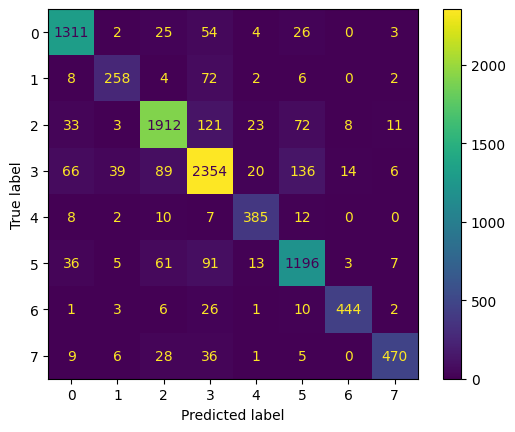


Classification Report:
                        precision    recall  f1-score   support

               Access       0.89      0.92      0.91      1425
Administrative rights       0.81      0.73      0.77       352
           HR Support       0.90      0.88      0.89      2183
             Hardware       0.85      0.86      0.86      2724
     Internal Project       0.86      0.91      0.88       424
        Miscellaneous       0.82      0.85      0.83      1412
             Purchase       0.95      0.90      0.92       493
              Storage       0.94      0.85      0.89       555

             accuracy                           0.87      9568
            macro avg       0.88      0.86      0.87      9568
         weighted avg       0.87      0.87      0.87      9568



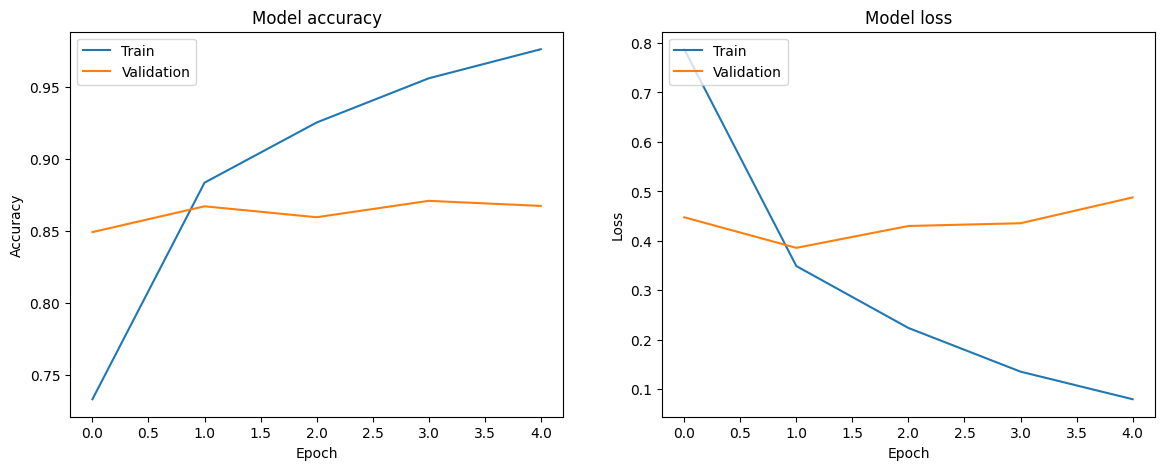

In [ ]:
# Displaying confusion matrix
ConfusionMatrixDisplay(conf_matrix).plot()
plt.show()

# Generating classification report
class_report = classification_report(y_true, y_pred, target_names=data["Topic_group"].astype('category').cat.categories)
print("\nClassification Report:\n", class_report)

# Ploting training & validation accuracy values
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Ploting training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()